# NeqSim + Tagreader: Connecting Process Models to Plant Data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/equinor/neqsim/blob/master/examples/notebooks/plant_data_tagreader_intro.ipynb)

This notebook demonstrates the **NeqSimLive development workflow** for connecting
NeqSim process simulations to real plant data from historians (OSIsoft PI, Aspen IP.21)
using the [tagreader-python](https://github.com/equinor/tagreader-python) package.

## Workflow

1. **Build a process model** using NeqSim
2. **Read plant data** with tagreader (or use mock data)
3. **Compare model to plant** and identify tuning needs
4. **Run a digital twin loop** — model tracks plant over time

## Process Overview

We model a simple gas compression train:

```
Feed Gas → [Inlet Sep] → [Compressor] → [Aftercooler] → Export
```

**Prerequisites:**
- `pip install neqsim tagreader matplotlib pandas numpy`
- For real plant data: access to an Equinor PI or Aspen IP.21 server
- Without historian access: the notebook uses mock data automatically

---
## Setup

In [1]:
# Install dependencies (uncomment if needed)
# !pip install neqsim tagreader matplotlib pandas numpy

In [3]:
import importlib, subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except Exception:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

NeqSim loaded via pip package


In [4]:
# Import NeqSim classes
if NEQSIM_MODE == "devtools":
    pass  # Classes already on ns.*
else:
    ns = type('ns', (), {})()
    ns.SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
    ns.ProcessSystem = jneqsim.process.processmodel.ProcessSystem
    ns.Stream = jneqsim.process.equipment.stream.Stream
    ns.Separator = jneqsim.process.equipment.separator.Separator
    ns.Compressor = jneqsim.process.equipment.compressor.Compressor
    ns.Cooler = jneqsim.process.equipment.heatexchanger.Cooler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

print("All imports ready")

All imports ready


---
## Step 1: Build the Process Model

Create a NeqSim process simulation that matches the real plant topology.
The model uses design conditions initially — these will be replaced with
actual plant data in Step 3.

In [5]:
# Define gas composition
fluid = ns.SystemSrkEos(273.15 + 25.0, 60.0)
fluid.addComponent("methane", 0.85)
fluid.addComponent("ethane", 0.07)
fluid.addComponent("propane", 0.04)
fluid.addComponent("i-butane", 0.01)
fluid.addComponent("n-butane", 0.01)
fluid.addComponent("nitrogen", 0.01)
fluid.addComponent("CO2", 0.01)
fluid.setMixingRule("classic")

# Design conditions
DESIGN_INLET_P = 29.0     # bara
DESIGN_INLET_T = 15.0     # degC
DESIGN_OUTLET_P = 90.0    # bara
DESIGN_FLOW = 100000.0    # kg/hr

# Build process
feed = ns.Stream("Feed Stream", fluid)
feed.setFlowRate(DESIGN_FLOW, "kg/hr")
feed.setTemperature(DESIGN_INLET_T, "C")
feed.setPressure(DESIGN_INLET_P, "bara")

sep = ns.Separator("Inlet Sep", feed)

comp = ns.Compressor("Compressor", sep.getGasOutStream())
comp.setOutletPressure(DESIGN_OUTLET_P, "bara")

aftercooler = ns.Cooler("Aftercooler", comp.getOutletStream())
aftercooler.setOutTemperature(273.15 + 30.0)

process = ns.ProcessSystem()
process.add(feed)
process.add(sep)
process.add(comp)
process.add(aftercooler)
process.run()

print("=== Process Model at Design Conditions ===")
print(f"  Suction P:      {float(comp.getInletStream().getPressure('bara')):.1f} bara")
print(f"  Suction T:      {float(comp.getInletStream().getTemperature('C')):.1f} \u00b0C")
print(f"  Discharge P:    {float(comp.getOutletStream().getPressure('bara')):.1f} bara")
print(f"  Discharge T:    {float(comp.getOutletStream().getTemperature('C')):.1f} \u00b0C")
print(f"  Power:          {float(comp.getPower('MW')):.2f} MW")
print(f"  Aftercooler T:  {float(aftercooler.getOutletStream().getTemperature('C')):.1f} \u00b0C")

=== Process Model at Design Conditions ===
  Suction P:      29.0 bara
  Suction T:      15.0 °C
  Discharge P:    90.0 bara
  Discharge T:    97.8 °C
  Power:          4.07 MW
  Aftercooler T:  30.0 °C


---
## Step 2: Read Plant Data with Tagreader

Connect to the plant historian (PI or IP.21), search for relevant tags,
and read historical process data.

**Set `USE_HISTORIAN = True`** if you have access to a historian server.
Otherwise the notebook uses mock data automatically.

In [6]:
# Configuration: set True when you have historian access
USE_HISTORIAN = False

if USE_HISTORIAN:
    import tagreader

    # Discover available sources
    print("PI sources:", tagreader.list_sources("piwebapi"))
    print("Aspen sources:", tagreader.list_sources("aspenone"))

    # Connect to data source (change name to match your plant)
    c = tagreader.IMSClient("PINO", "piwebapi")
    c.connect()
    print("Connected to historian")
else:
    c = None
    print("Running in DEMO mode with mock data")

Running in DEMO mode with mock data


In [7]:
# Define tag mapping: logical parameter name -> historian tag name
# Change these to match YOUR plant's tag naming convention

TAG_MAP = {
    # Compressor
    'comp_suction_P':     'PLANT-35PT3601A.PV',    # Suction pressure (bara)
    'comp_discharge_P':   'PLANT-35PT3601B.PV',    # Discharge pressure (bara)
    'comp_suction_T':     'PLANT-35TT3601A.PV',    # Suction temperature (\u00b0C)
    'comp_discharge_T':   'PLANT-35TT3601B.PV',    # Discharge temperature (\u00b0C)
    'comp_aftercool_T':   'PLANT-35TT3646.PV',     # Aftercooler outlet (\u00b0C)
    'comp_flow':          'PLANT-35FT3601.PV',     # Inlet flow
    'comp_power':         'PLANT-35JI3191F000.PV', # Motor power (MW)
    'comp_speed':         'PLANT-35SI3152.PV',     # Motor speed (RPM)

    # Export
    'export_pressure':    'PLANT-27PT0004.PV',     # Export pressure (bara)
}

print(f"Configured {len(TAG_MAP)} tags:")
for param, tag in TAG_MAP.items():
    print(f"  {param:25s} -> {tag}")

Configured 9 tags:
  comp_suction_P            -> PLANT-35PT3601A.PV
  comp_discharge_P          -> PLANT-35PT3601B.PV
  comp_suction_T            -> PLANT-35TT3601A.PV
  comp_discharge_T          -> PLANT-35TT3601B.PV
  comp_aftercool_T          -> PLANT-35TT3646.PV
  comp_flow                 -> PLANT-35FT3601.PV
  comp_power                -> PLANT-35JI3191F000.PV
  comp_speed                -> PLANT-35SI3152.PV
  export_pressure           -> PLANT-27PT0004.PV


In [8]:
# Read plant data from historian or generate mock data

START_TIME = "01.06.2025 06:00:00"
END_TIME   = "01.06.2025 18:00:00"
SAMPLE_INTERVAL = 300  # 5-minute intervals

if USE_HISTORIAN and c is not None:
    tags = list(TAG_MAP.values())
    df_plant = c.read(tags, START_TIME, END_TIME, SAMPLE_INTERVAL)
    print(f"Read {len(df_plant)} rows x {len(df_plant.columns)} tags from historian")
else:
    # Generate realistic mock data
    timestamps = pd.date_range(START_TIME, END_TIME, freq='5min')
    np.random.seed(42)
    n = len(timestamps)

    # Add a slow trend to make it realistic (e.g., pressure drift)
    trend = np.linspace(0, 1.5, n)  # slight upward drift

    df_plant = pd.DataFrame({
        TAG_MAP['comp_suction_P']:   np.random.normal(29.0, 0.2, n) - trend * 0.3,
        TAG_MAP['comp_discharge_P']: np.random.normal(90.0, 1.0, n) + trend * 0.5,
        TAG_MAP['comp_suction_T']:   np.random.normal(15.0, 0.5, n) + trend * 0.2,
        TAG_MAP['comp_discharge_T']: np.random.normal(95.0, 2.0, n) + trend * 0.8,
        TAG_MAP['comp_aftercool_T']: np.random.normal(30.0, 1.0, n),
        TAG_MAP['comp_flow']:        np.random.normal(100000, 3000, n),
        TAG_MAP['comp_power']:       np.random.normal(8.5, 0.3, n) + trend * 0.2,
        TAG_MAP['comp_speed']:       np.random.normal(9500, 100, n),
        TAG_MAP['export_pressure']:  np.random.normal(88.0, 1.0, n),
    }, index=timestamps)

    print(f"Generated mock plant data: {len(df_plant)} rows x {len(df_plant.columns)} tags")

print(f"Period: {df_plant.index[0]} to {df_plant.index[-1]}")
df_plant.describe().round(2)

Generated mock plant data: 145 rows x 9 tags
Period: 2025-01-06 06:00:00 to 2025-01-06 18:00:00


,PLANT-35PT3601A.PV,PLANT-35PT3601B.PV,PLANT-35TT3601A.PV,PLANT-35TT3601B.PV,PLANT-35TT3646.PV,PLANT-35FT3601.PV,PLANT-35JI3191F000.PV,PLANT-35SI3152.PV,PLANT-27PT0004.PV
count,145.00,145.00,145.00,145.00,145.00,145.00,145.00,145.00,145.00
mean,28.76,90.43,15.21,95.29,30.00,100271.74,8.70,9512.92,88.02
std,0.22,1.05,0.47,2.04,1.02,2841.94,0.30,101.01,1.02
min,28.23,87.37,14.13,90.70,27.30,94477.38,7.97,9210.37,85.50
25%,28.62,89.70,14.86,93.90,29.45,98165.45,8.50,9453.23,87.28
50%,28.76,90.46,15.19,95.16,29.97,100246.85,8.70,9515.04,88.04
75%,28.91,91.03,15.47,96.68,30.70,101975.63,8.91,9585.02,88.57
max,29.30,94.19,16.30,101.52,32.57,107897.15,9.42,9740.34,90.58


### Visualize Plant Data

Plot the raw plant data time series to inspect quality and identify anomalies.

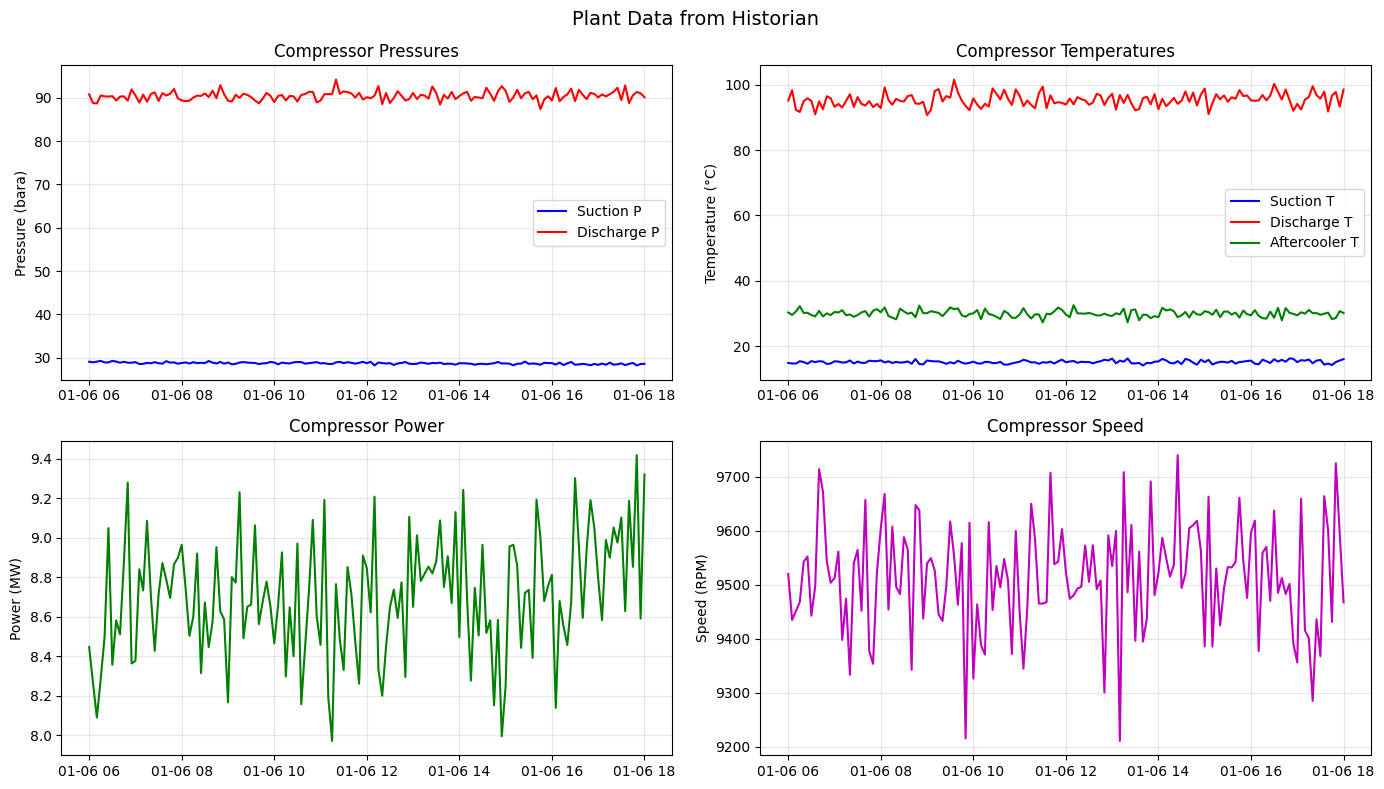

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Plant Data from Historian', fontsize=14)

# Pressures
ax = axes[0, 0]
ax.plot(df_plant.index, df_plant[TAG_MAP['comp_suction_P']], 'b-', label='Suction P')
ax.plot(df_plant.index, df_plant[TAG_MAP['comp_discharge_P']], 'r-', label='Discharge P')
ax.set_ylabel('Pressure (bara)')
ax.set_title('Compressor Pressures')
ax.legend()
ax.grid(True, alpha=0.3)

# Temperatures
ax = axes[0, 1]
ax.plot(df_plant.index, df_plant[TAG_MAP['comp_suction_T']], 'b-', label='Suction T')
ax.plot(df_plant.index, df_plant[TAG_MAP['comp_discharge_T']], 'r-', label='Discharge T')
ax.plot(df_plant.index, df_plant[TAG_MAP['comp_aftercool_T']], 'g-', label='Aftercooler T')
ax.set_ylabel('Temperature (\u00b0C)')
ax.set_title('Compressor Temperatures')
ax.legend()
ax.grid(True, alpha=0.3)

# Power
ax = axes[1, 0]
ax.plot(df_plant.index, df_plant[TAG_MAP['comp_power']], 'g-')
ax.set_ylabel('Power (MW)')
ax.set_title('Compressor Power')
ax.grid(True, alpha=0.3)

# Speed
ax = axes[1, 1]
ax.plot(df_plant.index, df_plant[TAG_MAP['comp_speed']], 'm-')
ax.set_ylabel('Speed (RPM)')
ax.set_title('Compressor Speed')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plant_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 3: Compare Model to Plant Data

Re-run the NeqSim model using actual plant conditions as boundary inputs,
then compare simulated vs measured values.

In [10]:
# Helper to extract values by logical parameter name
def get_plant_value(df, tag_map, param_name, aggregation='mean'):
    """Get a plant value by logical parameter name."""
    tag = tag_map[param_name]
    if tag not in df.columns:
        return float('nan')
    series = df[tag].dropna()
    if len(series) == 0:
        return float('nan')
    agg_funcs = {
        'mean': series.mean, 'last': lambda: series.iloc[-1],
        'median': series.median, 'min': series.min, 'max': series.max
    }
    return float(agg_funcs.get(aggregation, series.mean)())

# Extract period-average conditions
plant_suction_P = get_plant_value(df_plant, TAG_MAP, 'comp_suction_P')
plant_suction_T = get_plant_value(df_plant, TAG_MAP, 'comp_suction_T')
plant_discharge_P = get_plant_value(df_plant, TAG_MAP, 'comp_discharge_P')
plant_discharge_T = get_plant_value(df_plant, TAG_MAP, 'comp_discharge_T')
plant_power = get_plant_value(df_plant, TAG_MAP, 'comp_power')

print(f"Plant average conditions:")
print(f"  Suction P:    {plant_suction_P:.1f} bara")
print(f"  Suction T:    {plant_suction_T:.1f} \u00b0C")
print(f"  Discharge P:  {plant_discharge_P:.1f} bara")
print(f"  Discharge T:  {plant_discharge_T:.1f} \u00b0C")
print(f"  Power:        {plant_power:.2f} MW")

Plant average conditions:
  Suction P:    28.8 bara
  Suction T:    15.2 °C
  Discharge P:  90.4 bara
  Discharge T:  95.3 °C
  Power:        8.70 MW


In [11]:
# Update model with plant boundary conditions
inlet_stream = process.getUnit("Feed Stream")
inlet_stream.setPressure(float(plant_suction_P), "bara")
inlet_stream.setTemperature(float(plant_suction_T), "C")

comp_unit = process.getUnit("Compressor")
comp_unit.setOutletPressure(float(plant_discharge_P), "bara")

process.run()

# Build comparison table
sim_suction_P = float(comp_unit.getInletStream().getPressure('bara'))
sim_discharge_P = float(comp_unit.getOutletStream().getPressure('bara'))
sim_discharge_T = float(comp_unit.getOutletStream().getTemperature('C'))
sim_power = float(comp_unit.getPower('MW'))

comparison = []
for param, pv, sv in [
    ('Suction P (bara)', plant_suction_P, sim_suction_P),
    ('Discharge P (bara)', plant_discharge_P, sim_discharge_P),
    ('Discharge T (\u00b0C)', plant_discharge_T, sim_discharge_T),
    ('Power (MW)', plant_power, sim_power),
]:
    if not math.isnan(pv):
        comparison.append({
            'Parameter': param,
            'Plant': round(pv, 2),
            'Simulated': round(sv, 2),
            'Delta': round(sv - pv, 2),
            'Delta %': round((sv - pv) / max(abs(pv), 0.01) * 100, 1),
        })

df_cmp = pd.DataFrame(comparison)
print("\n=== SIMULATED vs PLANT DATA ===")
print(df_cmp.to_string(index=False))
print("\nLarge deltas indicate where the model needs tuning.")


=== SIMULATED vs PLANT DATA ===
         Parameter  Plant  Simulated  Delta  Delta %
  Suction P (bara)  28.76      28.76   0.00      0.0
Discharge P (bara)  90.43      90.43   0.00      0.0
  Discharge T (°C)  95.29      98.99   3.70      3.9
        Power (MW)   8.70       4.13  -4.57    -52.5

Large deltas indicate where the model needs tuning.


---
## Step 4: Digital Twin Loop

Run the NeqSim model at each plant data timestep to create a continuous
tracking record. This is the same pattern used in **NeqSimLive** for
real-time operation via Sigma/IOC.

In [12]:
# Run model at every timestep
results = []
inlet_stream = process.getUnit("Feed Stream")
comp_unit = process.getUnit("Compressor")

STEP = 1  # Process every N-th row (increase for speed during prototyping)

print(f"Running digital twin loop: {len(range(0, len(df_plant), STEP))} timesteps...")

for i in range(0, len(df_plant), STEP):
    row = df_plant.iloc[i]
    ts = df_plant.index[i]

    # Read plant inputs
    p_in = float(row[TAG_MAP['comp_suction_P']])
    t_in = float(row[TAG_MAP['comp_suction_T']])
    p_out = float(row[TAG_MAP['comp_discharge_P']])

    # Skip bad data
    if math.isnan(p_in) or p_in <= 0 or math.isnan(t_in) or t_in < -50:
        continue

    # Update model
    inlet_stream.setPressure(p_in, "bara")
    inlet_stream.setTemperature(t_in, "C")
    if not math.isnan(p_out) and p_out > p_in:
        comp_unit.setOutletPressure(p_out, "bara")

    try:
        process.run()
        results.append({
            'timestamp': ts,
            'inlet_P': p_in,
            'inlet_T': t_in,
            'sim_discharge_T': float(comp_unit.getOutletStream().getTemperature('C')),
            'plant_discharge_T': float(row[TAG_MAP['comp_discharge_T']]),
            'sim_power_MW': float(comp_unit.getPower('MW')),
            'plant_power_MW': float(row[TAG_MAP['comp_power']]),
        })
    except Exception as e:
        pass  # Skip failed timesteps

df_results = pd.DataFrame(results)
print(f"Completed {len(df_results)} timesteps")
df_results.head()

Running digital twin loop: 145 timesteps...
Completed 145 timesteps


,timestamp,inlet_P,inlet_T,sim_discharge_T,plant_discharge_T,sim_power_MW,plant_power_MW
0,2025-01-06 06:00:00,29.099343,14.895939,98.099780,95.148190,4.092639,8.446916
1,2025-01-06 06:05:00,28.969222,14.755583,96.513998,98.265564,4.017559,8.262594
2,2025-01-06 06:10:00,29.123288,14.709484,96.007958,92.256464,3.990090,8.090371
3,2025-01-06 06:15:00,29.295231,15.431051,97.980833,91.618235,4.061971,8.286971
4,2025-01-06 06:20:00,28.940669,15.186841,98.413439,94.922238,4.100742,8.498395


### Digital Twin: Simulated vs Plant Over Time

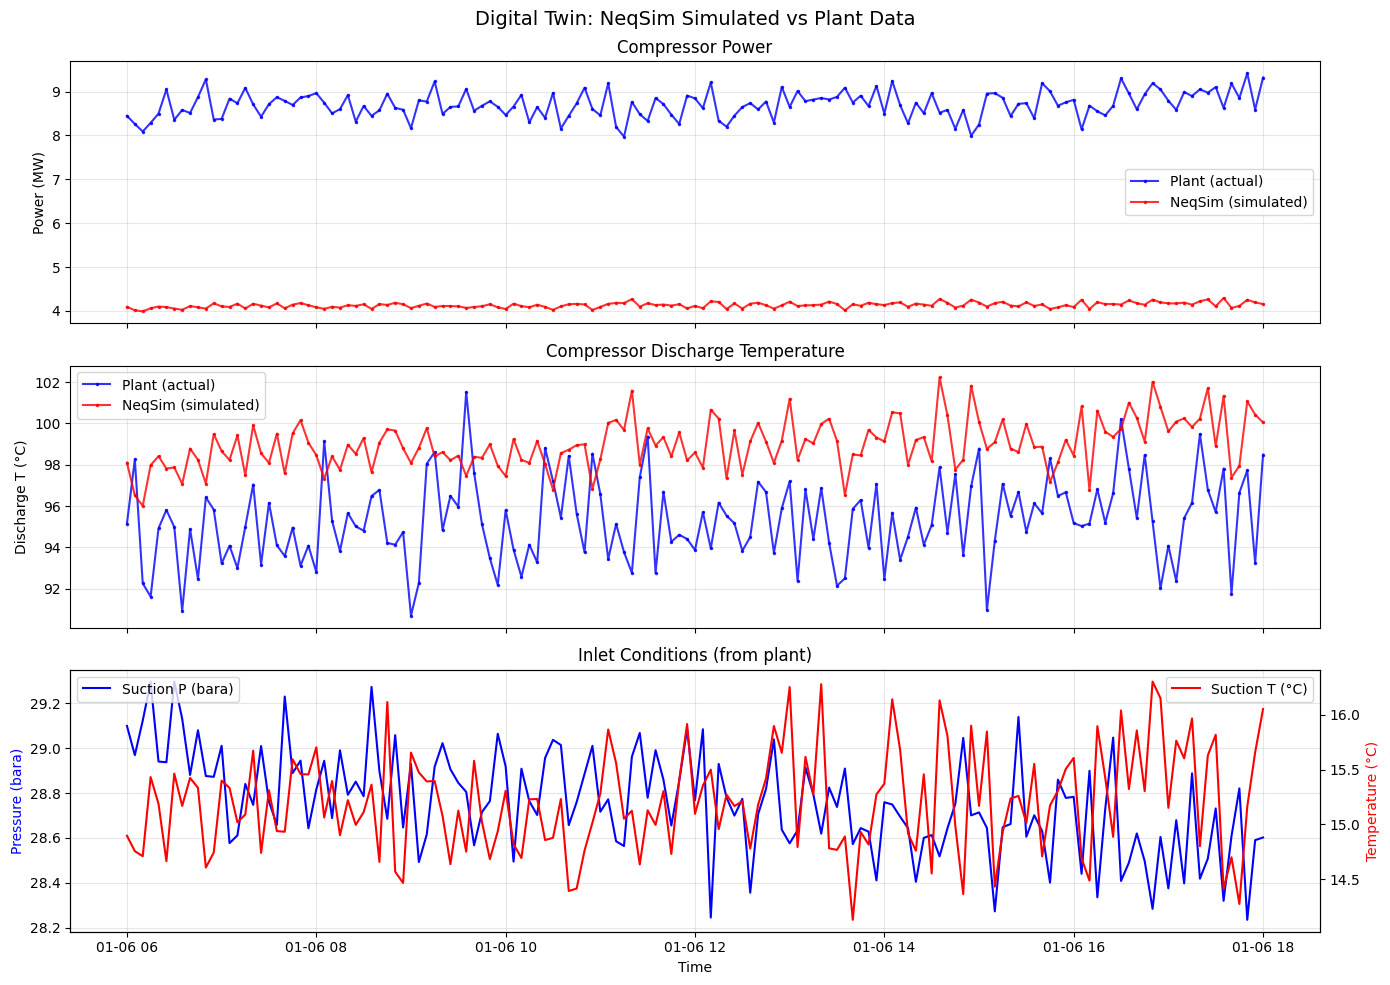

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Digital Twin: NeqSim Simulated vs Plant Data', fontsize=14)

# Power comparison
ax = axes[0]
ax.plot(df_results['timestamp'], df_results['plant_power_MW'],
        'b.-', markersize=3, label='Plant (actual)', alpha=0.8)
ax.plot(df_results['timestamp'], df_results['sim_power_MW'],
        'r.-', markersize=3, label='NeqSim (simulated)', alpha=0.8)
ax.set_ylabel('Power (MW)')
ax.set_title('Compressor Power')
ax.legend()
ax.grid(True, alpha=0.3)

# Temperature comparison
ax = axes[1]
ax.plot(df_results['timestamp'], df_results['plant_discharge_T'],
        'b.-', markersize=3, label='Plant (actual)', alpha=0.8)
ax.plot(df_results['timestamp'], df_results['sim_discharge_T'],
        'r.-', markersize=3, label='NeqSim (simulated)', alpha=0.8)
ax.set_ylabel('Discharge T (\u00b0C)')
ax.set_title('Compressor Discharge Temperature')
ax.legend()
ax.grid(True, alpha=0.3)

# Inlet conditions
ax = axes[2]
ax.plot(df_results['timestamp'], df_results['inlet_P'], 'b-', label='Suction P (bara)')
ax2 = ax.twinx()
ax2.plot(df_results['timestamp'], df_results['inlet_T'], 'r-', label='Suction T (\u00b0C)')
ax.set_ylabel('Pressure (bara)', color='b')
ax2.set_ylabel('Temperature (\u00b0C)', color='r')
ax.set_xlabel('Time')
ax.set_title('Inlet Conditions (from plant)')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('digital_twin_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Parity Plot: Model Accuracy

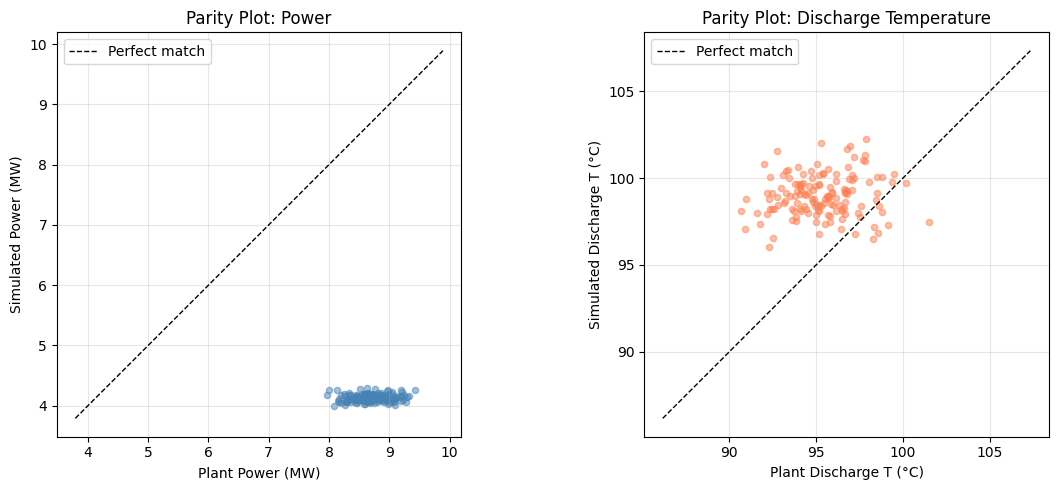

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Power parity
ax = axes[0]
ax.scatter(df_results['plant_power_MW'], df_results['sim_power_MW'],
           alpha=0.5, s=20, c='steelblue')
lims = [df_results[['plant_power_MW', 'sim_power_MW']].min().min() * 0.95,
        df_results[['plant_power_MW', 'sim_power_MW']].max().max() * 1.05]
ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect match')
ax.set_xlabel('Plant Power (MW)')
ax.set_ylabel('Simulated Power (MW)')
ax.set_title('Parity Plot: Power')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)

# Temperature parity
ax = axes[1]
ax.scatter(df_results['plant_discharge_T'], df_results['sim_discharge_T'],
           alpha=0.5, s=20, c='coral')
lims = [df_results[['plant_discharge_T', 'sim_discharge_T']].min().min() * 0.95,
        df_results[['plant_discharge_T', 'sim_discharge_T']].max().max() * 1.05]
ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect match')
ax.set_xlabel('Plant Discharge T (\u00b0C)')
ax.set_ylabel('Simulated Discharge T (\u00b0C)')
ax.set_title('Parity Plot: Discharge Temperature')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('parity_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### Model Accuracy Statistics

In [15]:
# Calculate accuracy metrics
valid = df_results.dropna(subset=['plant_power_MW', 'sim_power_MW',
                                   'plant_discharge_T', 'sim_discharge_T'])

power_err = (valid['sim_power_MW'] - valid['plant_power_MW']).abs()
temp_err = (valid['sim_discharge_T'] - valid['plant_discharge_T']).abs()

print("=== MODEL ACCURACY ===")
print(f"\nPower:")
print(f"  Mean Absolute Error: {power_err.mean():.3f} MW")
print(f"  Max Error:           {power_err.max():.3f} MW")
print(f"  MAPE:                {power_err.mean() / valid['plant_power_MW'].mean() * 100:.1f}%")
print(f"  RMSE:                {((valid['sim_power_MW'] - valid['plant_power_MW'])**2).mean()**0.5:.3f} MW")

print(f"\nDischarge Temperature:")
print(f"  Mean Absolute Error: {temp_err.mean():.1f} \u00b0C")
print(f"  Max Error:           {temp_err.max():.1f} \u00b0C")
print(f"  MAPE:                {temp_err.mean() / valid['plant_discharge_T'].mean() * 100:.1f}%")

=== MODEL ACCURACY ===

Power:
  Mean Absolute Error: 4.568 MW
  Max Error:           5.224 MW
  MAPE:                52.5%
  RMSE:                4.577 MW

Discharge Temperature:
  Mean Absolute Error: 3.9 °C
  Max Error:           8.8 °C
  MAPE:                4.1%


---
## Tagreader Quick Reference

| Operation | Code |
|-----------|------|
| List PI sources | `tagreader.list_sources("piwebapi")` |
| List Aspen sources | `tagreader.list_sources("aspenone")` |
| Connect | `c = tagreader.IMSClient("NAME", "piwebapi"); c.connect()` |
| Search tags | `c.search("*pattern*")` or `c.search(desc="*keyword*")` |
| Read interpolated | `c.read(tags, start, end, interval)` |
| Read average | `c.read(tags, start, end, interval, read_type=tagreader.ReaderType.AVG)` |
| Read raw | `c.read(tags, start, end, read_type=tagreader.ReaderType.RAW)` |
| Read snapshot | `c.read([tag], read_type=tagreader.ReaderType.SNAPSHOT)` |
| With quality | `c.read(tags, start, end, 60, get_status=True)` |

## Next Steps

- **Tune the model**: Adjust compressor efficiency, fluid composition, or heat loss to reduce deltas
- **Deploy via NeqSimAPI**: [neqsimapi.app.radix.equinor.com/docs](https://neqsimapi.app.radix.equinor.com/docs)
- **Go live with Sigma**: Connect live PI/Aspen tags to the API for 24/7 operation
- **What-if scenarios**: Run the calibrated model with future conditions

## Resources

- [tagreader-python](https://github.com/equinor/tagreader-python) — Python package for PI and IP.21
- [NeqSim](https://equinor.github.io/neqsimhome/) — Thermodynamic and process simulation
- [Digital Twin Integration Guide](https://equinor.github.io/neqsim/process/digital-twin-integration) — Architecture for production twins